Analyzing compression for 'Bappa.jpg'...

--- Image Compression Analysis ---
 Quality Factor Compression Ratio   BPP PSNR (dB)   SSIM
             90            0.36:1 5.388     44.52 0.9895
             75            0.45:1 4.362     37.24 0.9734
             50            0.50:1 3.855     33.89 0.9488
             25            0.55:1 3.508     31.25 0.9030
             10            0.60:1 3.232     27.78 0.7951


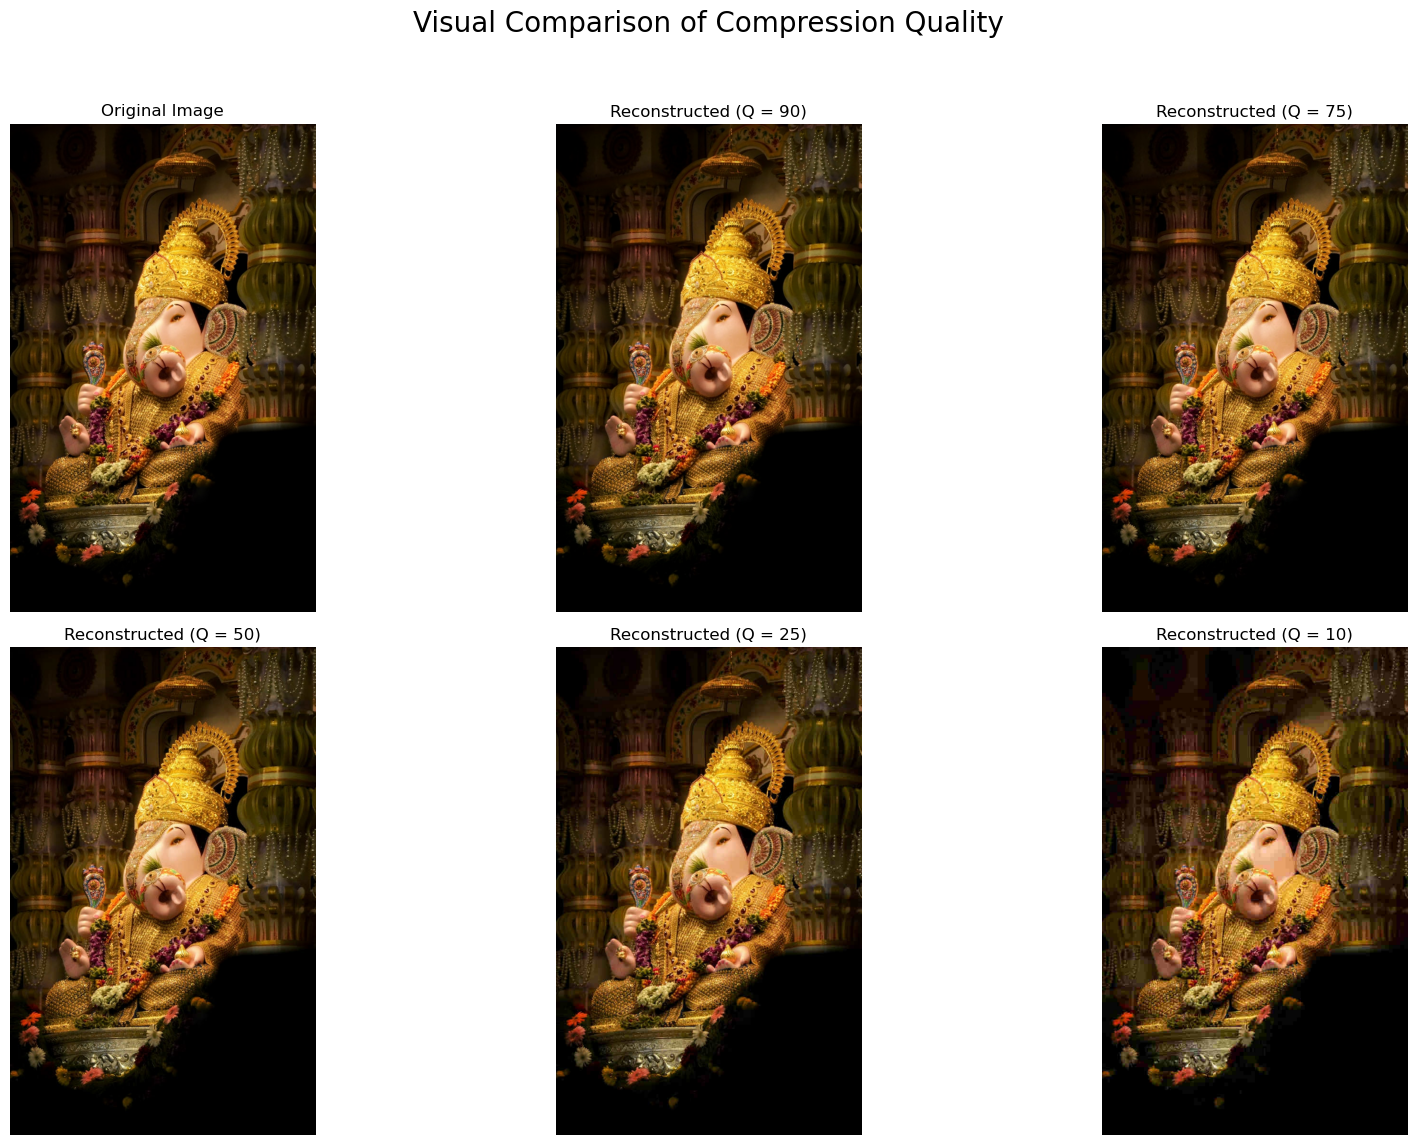

In [25]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.fft import dctn, idctn
import heapq
from collections import Counter
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import os

# --- 1. Quantization Table & Scaling ---

# Standard JPEG Luminance Quantization Table
Q_LUM = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
])

def get_scaled_q_table(quality_factor):
    """Scales the quantization table based on the quality factor (1-100)."""
    if quality_factor <= 0:
        quality_factor = 1
    if quality_factor > 100:
        quality_factor = 100
        
    if quality_factor < 50:
        scale = 5000 / quality_factor
    else:
        scale = 200 - 2 * quality_factor
        
    scale /= 100.0
    
    scaled_q = np.floor(Q_LUM * scale)
    scaled_q[scaled_q == 0] = 1
    scaled_q[scaled_q > 255] = 255
    return scaled_q.astype(np.uint8)

# --- 2. Huffman Coding Implementation ---

class HuffmanNode:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq

def build_huffman_tree(data):
    frequency = Counter(data)
    priority_queue = [HuffmanNode(char, freq) for char, freq in frequency.items()]
    heapq.heapify(priority_queue)

    while len(priority_queue) > 1:
        left = heapq.heappop(priority_queue)
        right = heapq.heappop(priority_queue)
        merged = HuffmanNode(None, left.freq + right.freq)
        merged.left = left
        merged.right = right
        heapq.heappush(priority_queue, merged)
    return priority_queue[0]

def generate_huffman_codes(root, current_code="", codes={}):
    if root is None: return {}
    if root.char is not None:
        codes[root.char] = current_code
        return codes
    generate_huffman_codes(root.left, current_code + "0", codes)
    generate_huffman_codes(root.right, current_code + "1", codes)
    return codes

def huffman_encode(data, codes):
    return "".join(codes[char] for char in data)

def huffman_decode(encoded_data, root):
    decoded_output = []
    current_node = root
    for bit in encoded_data:
        if bit == '0':
            current_node = current_node.left
        else:
            current_node = current_node.right
        
        if current_node.char is not None:
            decoded_output.append(current_node.char)
            current_node = root
    return decoded_output

# --- 3. Zigzag Scan Order ---

ZIGZAG_ORDER = np.array([
     0,  1,  8, 16,  9,  2,  3, 10, 17, 24, 32, 25, 18, 11,  4,  5,
    12, 19, 26, 33, 40, 48, 41, 34, 27, 20, 13,  6,  7, 14, 21, 28,
    35, 42, 49, 56, 57, 50, 43, 36, 29, 22, 15, 23, 30, 37, 44, 51,
    58, 59, 52, 45, 38, 31, 39, 46, 53, 60, 61, 54, 47, 55, 62, 63
])

# --- 4. Compression and Decompression Functions (Unchanged) ---

def compress_channel(channel, quality_factor):
    q_table = get_scaled_q_table(quality_factor)
    h, w = channel.shape
    quantized_coeffs_list = []
    
    for y in range(0, h, 8):
        for x in range(0, w, 8):
            block = channel[y:y+8, x:x+8].astype(np.float32) - 128
            dct_block = dctn(block, type=2, norm='ortho')
            quantized_block = np.round(dct_block / q_table).astype(np.int16)
            quantized_coeffs_list.extend(quantized_block.flatten()[ZIGZAG_ORDER])
            
    huffman_tree = build_huffman_tree(quantized_coeffs_list)
    huffman_codes = generate_huffman_codes(huffman_tree, "", {})
    encoded_data = huffman_encode(quantized_coeffs_list, huffman_codes)
    return encoded_data, huffman_tree

def decompress_channel(encoded_data, huffman_tree, shape, quality_factor):
    h, w = shape
    q_table = get_scaled_q_table(quality_factor)
    decoded_coeffs = huffman_decode(encoded_data, huffman_tree)
    
    reconstructed_channel = np.zeros(shape)
    coeff_index = 0
    
    for y in range(0, h, 8):
        for x in range(0, w, 8):
            zigzag_block = np.array(decoded_coeffs[coeff_index:coeff_index+64])
            inverse_zigzag_block = zigzag_block[np.argsort(ZIGZAG_ORDER)].reshape(8, 8)
            coeff_index += 64
            
            dequantized_block = inverse_zigzag_block * q_table
            idct_block = idctn(dequantized_block, type=2, norm='ortho')
            reconstructed_channel[y:y+8, x:x+8] = idct_block + 128
    
    return np.clip(reconstructed_channel, 0, 255).astype(np.uint8)

# --- 5. Main Analysis ---

# Define the path to your image
image_path = 'C:/Users/dhira/Downloads/Bappa.jpg'

# Load the image
original_image_bgr = cv2.imread(image_path)

if original_image_bgr is None:
    raise FileNotFoundError(f"Image not found at path: {image_path}. Please check the path and try again.")

# Convert to RGB for display and metrics, and YCrCb for processing
original_image_rgb = cv2.cvtColor(original_image_bgr, cv2.COLOR_BGR2RGB)
original_image_ycrcb = cv2.cvtColor(original_image_bgr, cv2.COLOR_BGR2YCrCb)

# Split channels
y, cr, cb = cv2.split(original_image_ycrcb)
h, w, _ = original_image_rgb.shape

# Pad each channel to be a multiple of 8
pad_h = (8 - h % 8) % 8
pad_w = (8 - w % 8) % 8
y_padded = cv2.copyMakeBorder(y, 0, pad_h, 0, pad_w, cv2.BORDER_REPLICATE)
cr_padded = cv2.copyMakeBorder(cr, 0, pad_h, 0, pad_w, cv2.BORDER_REPLICATE)
cb_padded = cv2.copyMakeBorder(cb, 0, pad_h, 0, pad_w, cv2.BORDER_REPLICATE)

# Define quality factors to test
quality_factors = [90, 75, 50, 25, 10]
results = []
reconstructed_images = {}

print(f"Analyzing compression for '{os.path.basename(image_path)}'...")

for qf in quality_factors:
    # --- Compress each channel ---
    encoded_y, tree_y = compress_channel(y_padded, qf)
    encoded_cr, tree_cr = compress_channel(cr_padded, qf)
    encoded_cb, tree_cb = compress_channel(cb_padded, qf)

    # --- Decompress each channel ---
    recon_y = decompress_channel(encoded_y, tree_y, y_padded.shape, qf)
    recon_cr = decompress_channel(encoded_cr, tree_cr, cr_padded.shape, qf)
    recon_cb = decompress_channel(encoded_cb, tree_cb, cb_padded.shape, qf)
    
    # --- Merge, Unpad, and Convert back to RGB ---
    reconstructed_padded_ycrcb = cv2.merge([recon_y, recon_cr, recon_cb])
    reconstructed_ycrcb = reconstructed_padded_ycrcb[0:h, 0:w] # Unpad
    reconstructed_rgb = cv2.cvtColor(reconstructed_ycrcb, cv2.COLOR_YCrCb2RGB)
    reconstructed_images[qf] = reconstructed_rgb
    
    # --- Metric Calculation ---
    original_size_bits = os.path.getsize(image_path) * 8
    compressed_size_bits = len(encoded_y) + len(encoded_cr) + len(encoded_cb)
    
    compression_ratio = original_size_bits / compressed_size_bits
    bpp = compressed_size_bits / (h * w)
    current_psnr = psnr(original_image_rgb, reconstructed_rgb, data_range=255)
    # For newer scikit-image versions, channel_axis is preferred
    current_ssim = ssim(original_image_rgb, reconstructed_rgb, data_range=255, channel_axis=2)
    
    results.append({
        "Quality Factor": qf,
        "Compression Ratio": f"{compression_ratio:.2f}:1",
        "BPP": f"{bpp:.3f}",
        "PSNR (dB)": f"{current_psnr:.2f}",
        "SSIM": f"{current_ssim:.4f}"
    })

# --- 6. Display Results ---

results_df = pd.DataFrame(results)
print("\n--- Image Compression Analysis ---")
print(results_df.to_string(index=False))

# Display the original and reconstructed images
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Visual Comparison of Compression Quality', fontsize=20)

axes[0, 0].imshow(original_image_rgb)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

for i, qf in enumerate(quality_factors, 1):
    ax = axes[i // 3, i % 3]
    ax.imshow(reconstructed_images[qf])
    ax.set_title(f'Reconstructed (Q = {qf})')
    ax.axis('off')

if len(quality_factors) + 1 < 6:
    axes[1, 2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()